In [140]:
import pandas as pd
import sys
import importlib

In [141]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split
import preprocessing as prep
import knn as knn

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(split)
importlib.reload(prep)
importlib.reload(knn)

<module 'knn' from '/Users/isacassanello/Desktop/tercero/aprendizaje automatico y profundo/TP_Final_ML/notebooks/../src/knn.py'>

In [143]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Exploratory Data Analysis
</h1>

In [144]:
# Columns visualization with their types
feature_types = eda.feature_types_summary(dataset)
display(feature_types.style.hide(axis="index"))

column,dtype
Precio,float64
Año,float64
Puertas,float64
Unnamed: 0,int64
Moneda,object
Título,object
Kilómetros,object
Con cámara de retroceso,object
Tipo de carrocería,object
Transmisión,object


In [145]:
# Shape of the dataset
print(f"Cantidad de filas: {dataset.shape[0]}")
print(f"Cantidad de columnas: {dataset.shape[1]}")

Cantidad de filas: 18254
Cantidad de columnas: 18


In [146]:
# Split the dataset into input features (X) and the target variable (y) to be predicted
TARGET = "Precio"

X = dataset.drop(columns = [TARGET])
y = dataset[TARGET]

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Target Analysis
</h3>

In [147]:
target_summary = eda.explore_target(y, currency = X["Moneda"])
display(target_summary.style.hide(axis="index"))

group,count,missing,missing_%,min,q1,median,mean,q3,max,std,zero_count
All,18254,0,0.000000,111.000000,31900.000000,17200000.000000,17601617.476005,29950000.000000,349500000.000000,17208100.444408,0
$,11158,0,0.000000,119000.000000,19000000.000000,27320000.000000,28774610.530113,35900000.000000,349500000.000000,12778611.327716,0
US$,7096,0,0.000000,111.000000,16000.000000,24000.000000,32810.190530,38900.000000,610000.000000,28854.448542,0


#### Análisis de la tabla

Analizamos la distribución de la variable objetivo (`Precio`) y la segmentamos por moneda de publicación. En la tabla se observa que no hay valores faltantes ni precios iguales a cero en la variable objetivo. Además, las publicaciones en pesos presentan valores mucho más altos que las publicaciones en dólares, evidenciando una diferencia de órdenes de magnitud entre ambas monedas. Por este motivo, resulta necesario unificar la unidad monetaria antes del modelado.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Duplicate Rows Analysis
</div>

Verificamos la existencia de filas completamente duplicadas en el conjunto de datos para identificar posibles publicaciones repetidas o errores de recolección

In [148]:
eda.duplicate_rows_summary(dataset).style.hide(axis="index")

total_rows,duplicate_rows
18254,0


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Values Analysis
</div>

La mayoría de las variables presentan una cantidad de valores faltantes muy reducida. La principal excepción es `Con cámara de retroceso`, con un 74,30% de datos ausentes. Por este motivo, esta variable requerirá un tratamiento particular durante el preprocesamiento.

In [149]:
eda.missing_values_summary(dataset).style.hide(axis="index")

column,missing_count,missing_percentage
Con cámara de retroceso,13563,74.300000
Color,389,2.130000
Motor,38,0.210000
Transmisión,15,0.080000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Feature Cardinality Analysis
</div>

Calculamos la cantidad y el porcentaje de valores únicos de cada variable para identificar posibles identificadores, variables de texto libre y atributos categóricos de baja o alta cardinalidad. Se observa que `Unnamed: 0` contiene valores completamente únicos y actúa como un identificador, mientras que `Título` y `Descripción` presentan una elevada diversidad de valores, característica esperable en variables de texto libre

In [150]:
eda.unique_values_summary(dataset).style.hide(axis="index")

column,unique_values,unique_pct
Unnamed: 0,18254,100.000000
Descripción,12142,66.520000
Precio,2914,15.960000
Título,2220,12.160000
Kilómetros,2175,11.920000
Versión,2072,11.350000
Motor,271,1.480000
Modelo,137,0.750000
Color,70,0.380000
Marca,47,0.260000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Repetitions Analysis
</div>

Analizamos las variables categóricas en busca de valores semánticamente equivalentes escritos de distintas maneras (por ejemplo, diferencias de mayúsculas, errores tipográficos o variantes de escritura). El objetivo es detectar categorías que representan el mismo concepto y deberían unificarse durante el preprocesamiento

In [151]:
categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de combustible",
    "Transmisión",
    "Tipo de vendedor",
]

semantic_repetitions = eda.find_semantic_repetitions(dataset, columns = categorical_columns, similarity_threshold=0.80)

semantic_repetitions

,feature,similar_values,normalized_values,total_count,n_values_grouped
0,Color,Blanco | Blanca | BLANCA | blanca,blanca | blanco,4818,4
1,Color,Negro | Negra | NEGRA,negra | negro,2830,3
2,Color,Dorado | MORADO,dorado | morado,191,2
3,Color,Amarillo | Amarrillo,amarillo | amarrillo,25,2
4,Color,Plata | PLATA,plata,9,2
5,Color,Gris plata | GRIS PLATA | GRIS PLATINO,gris plata | gris platino,5,3
6,Color,Marrón oscuro | Marrón claro,marron claro | marron oscuro,3,2
7,Color,BLANCO GLACIAR | Blanco Glaciar,blanco glaciar,2,2
8,Color,GRANITE CRYSTA BC | GRANITE CRYSTAL BC,granite crysta bc | granite crystal bc,2,2
9,Marca,Renault | Rrenault,renault | rrenault,1492,2


#### Análisis de la tabla

La tabla evidencia numerosas inconsistencias de representación, especialmente en las variables `Color`, `Marca` y `Modelo`. Se observan diferencias de capitalización (`Blanco`, `BLANCA`, `blanca`), errores tipográficos (`Renault` y `Renault`, `Jetour` y `Jetur`) y variantes de nomenclatura (`2008` y `208`, `X5` y `X55`). Estas inconsistencias fragmentan artificialmente las categorías y aumentan innecesariamente su cardinalidad, por lo que resulta conveniente normalizarlas antes del modelado

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Initial Graphics Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Categorical Variables
</div>

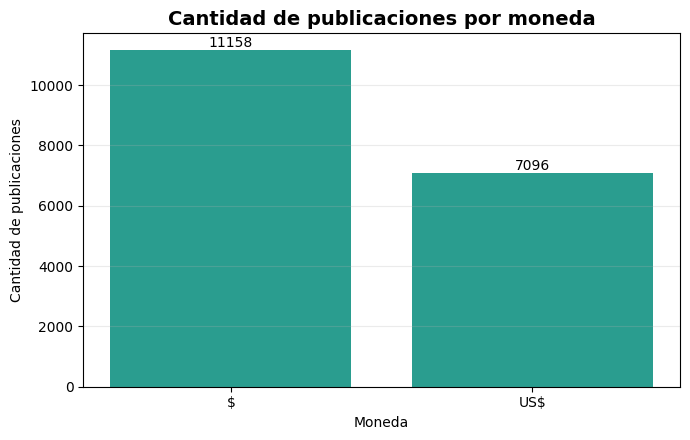

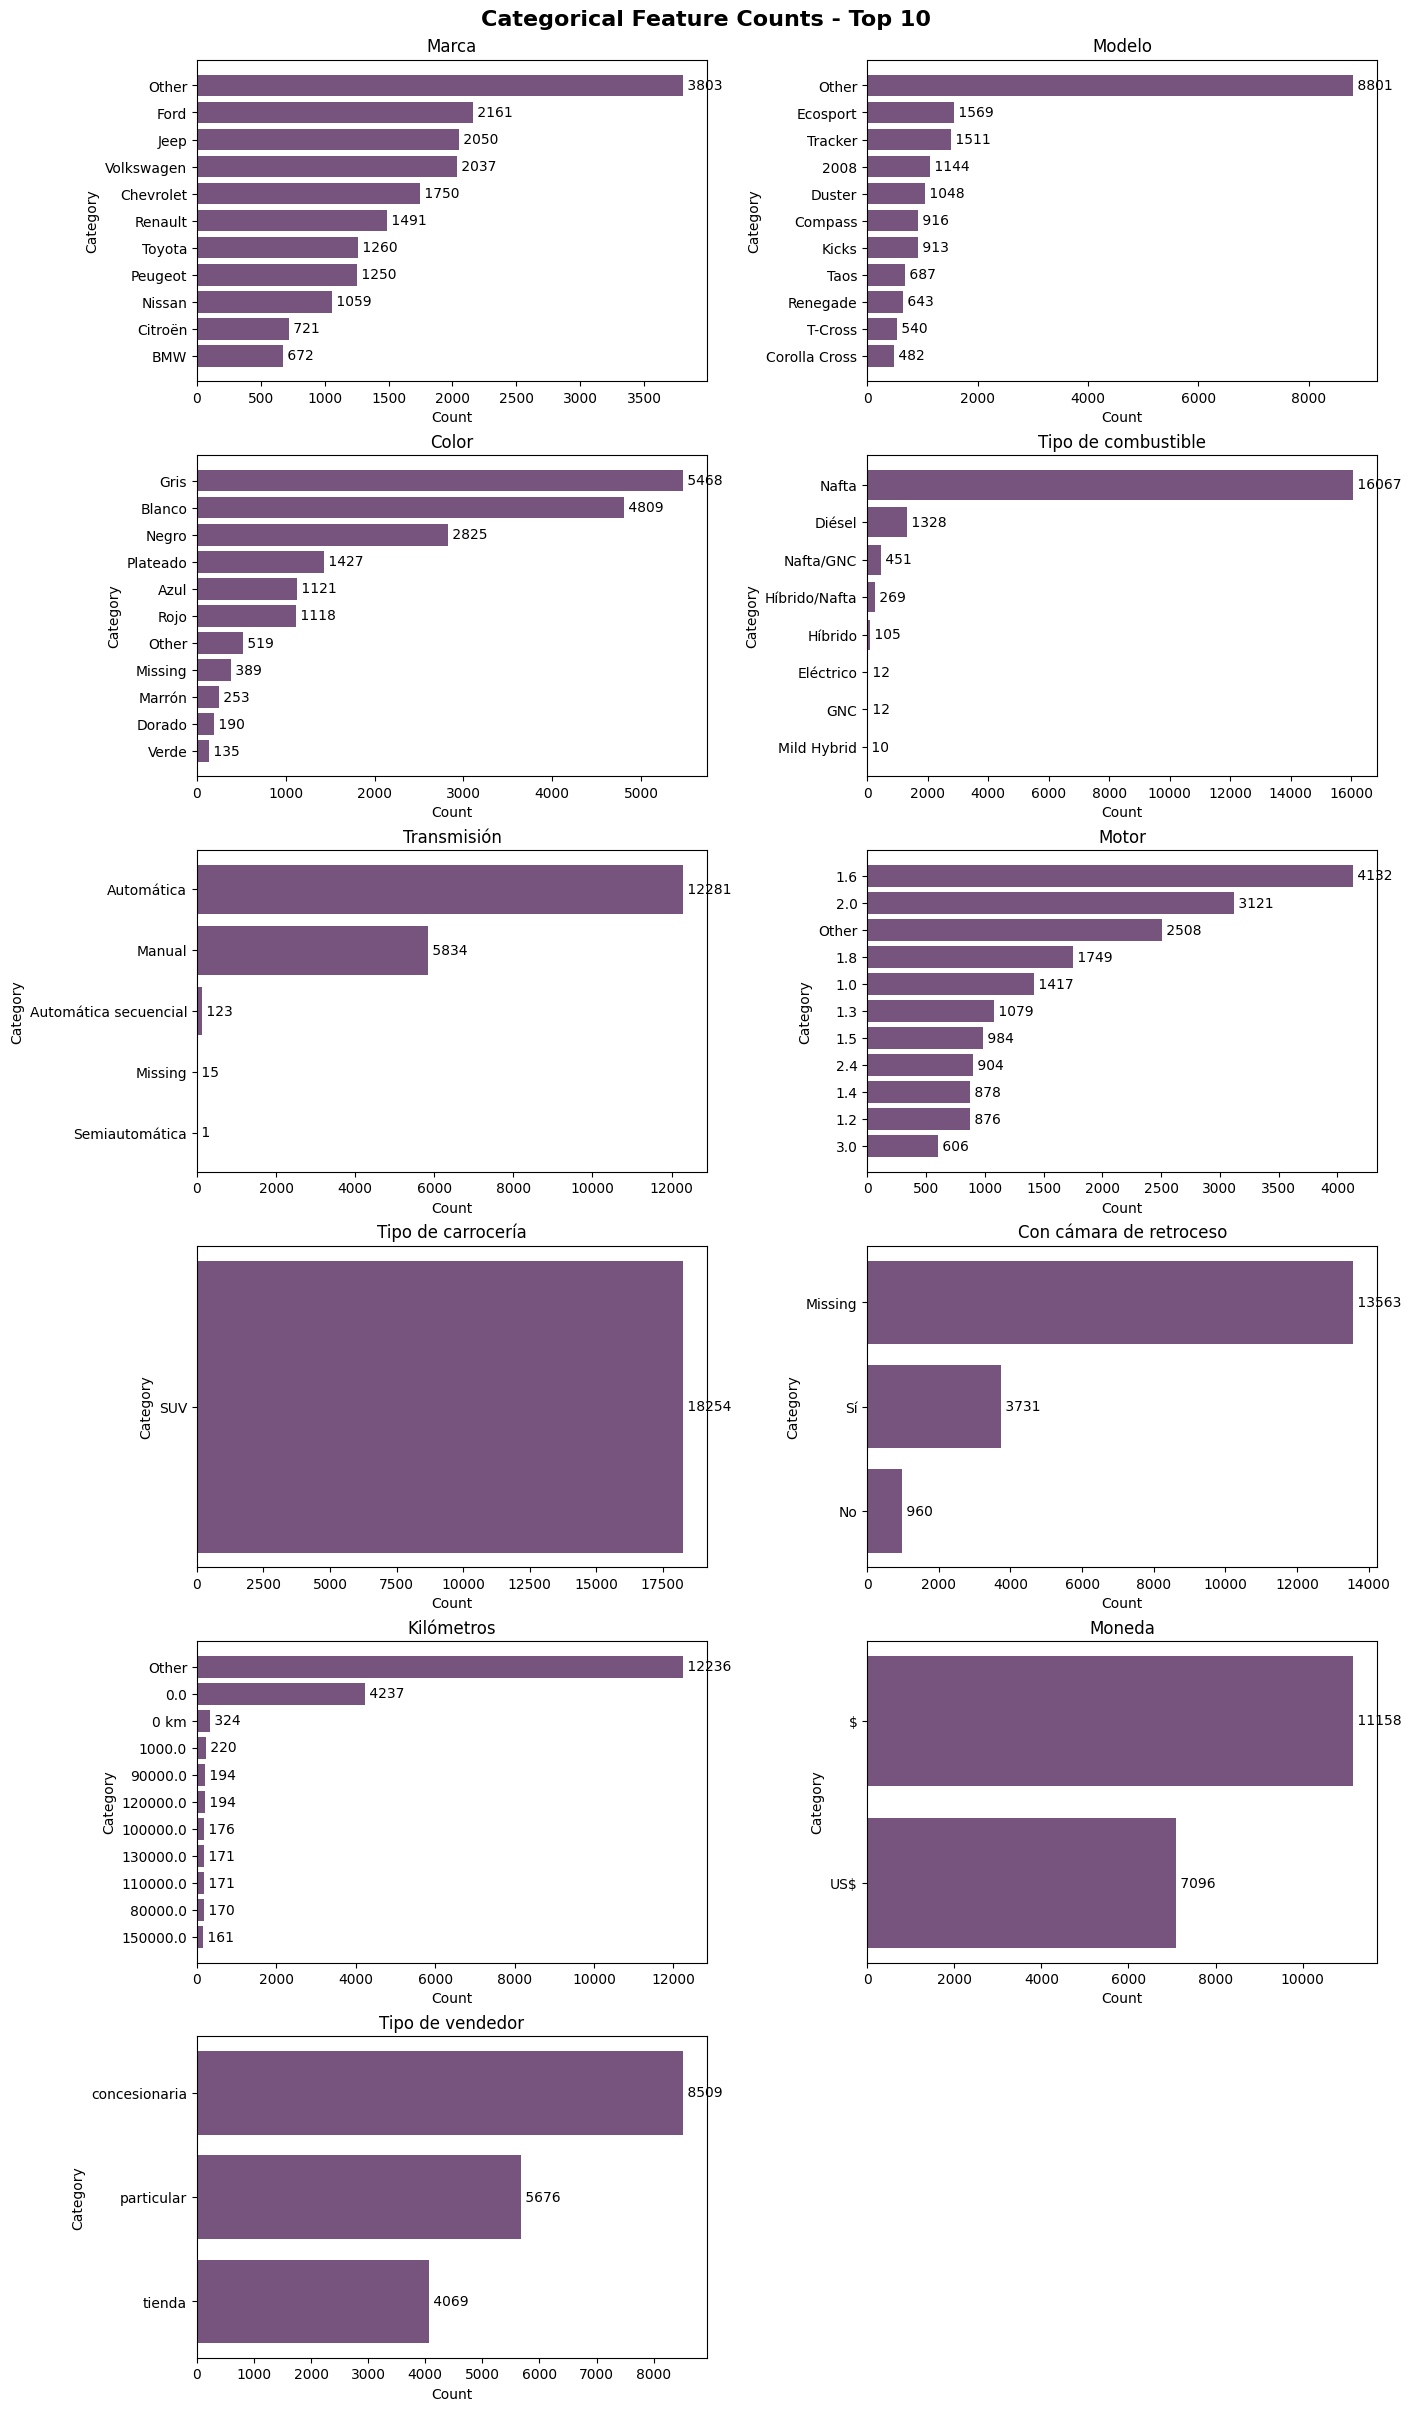

In [152]:
visual.plot_currency_counts(dataset)
visual.plot_categorical_counts(X, ignored_columns=["Título", "Descripción", "Versión"], top_n = 10, n_cols = 2)

#### Análisis gráfico 1
Se observa que una mayor cantidad de publicaciones se encuentran expresadas en pesos que en dólares. Dado que el precio objetivo está representado en ambas monedas, resulta necesario unificar la unidad monetaria antes del modelado para evitar diferencias artificiales de escala.

#### Análisis gráfico 2
Los gráficos muestran distribuciones heterogéneas entre las variables categóricas. Algunas presentan un fuerte desbalance de clases, como `Tipo de combustible`, dominada por publicaciones de vehículos nafteros, y `Transmisión`, donde predominan las cajas automáticas. También se observa una elevada proporción de valores faltantes en `Con cámara de retroceso`. En contraste, variables como `Marca`, `Modelo`, `Color` y `Tipo de vendedor` exhiben una mayor diversidad de categorías, lo que sugiere que podrían aportar información relevante al modelo predictivo


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numerical Variables
</div>

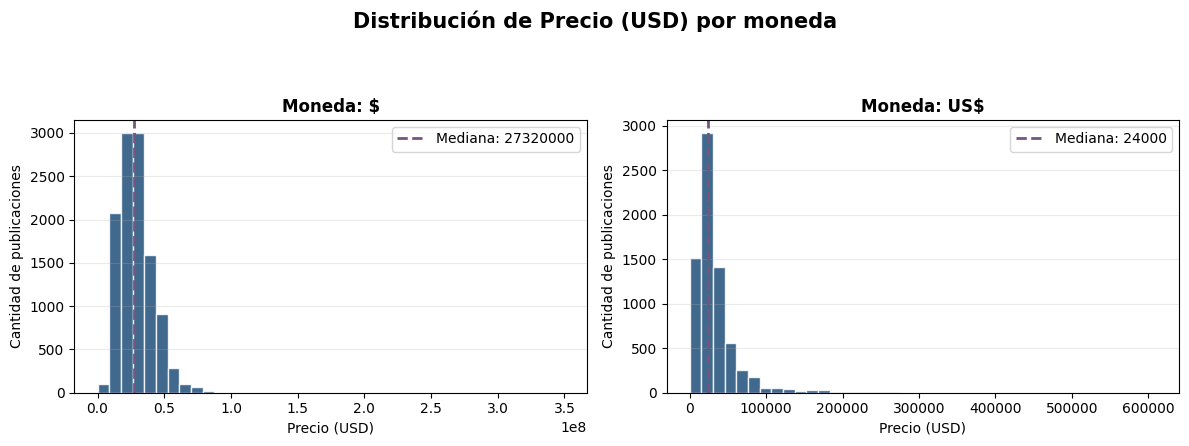

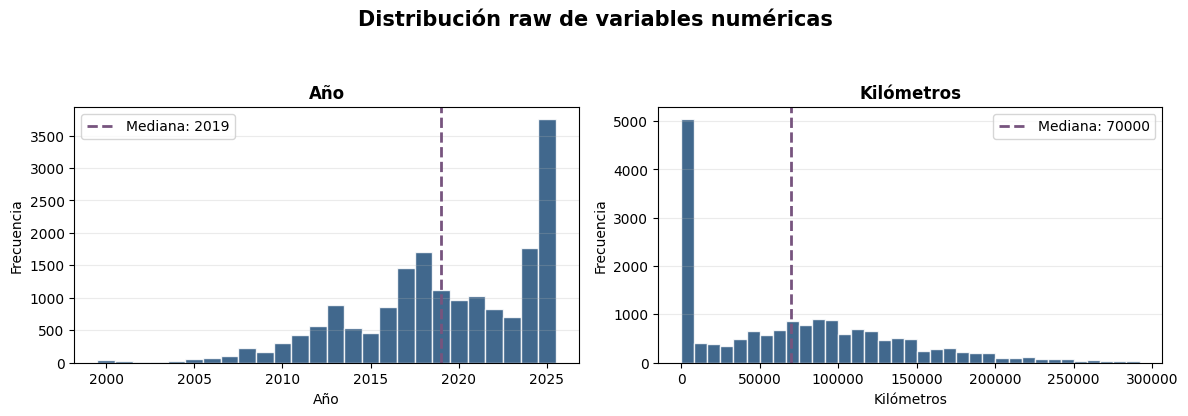

In [153]:
visual.plot_price_distribution_by_currency(dataset)
visual.plot_raw_numeric_distributions(dataset)

#### Análisis gráfico 1
Las distribuciones de precio presentan una marcada asimetría positiva en ambas monedas, con una alta concentración de publicaciones en valores relativamente bajos y una cola larga hacia precios elevados. Además, se observa una elevada dispersión y la presencia de algunos vehículos considerablemente más caros que la mayoría de las publicaciones. Este comportamiento sugiere la existencia de valores extremos y una distribución alejada de la normalidad, aspectos que deberán considerarse durante el preprocesamiento y el modelado

#### Análisis gráfico 2
La distribución de `Año` se encuentra sesgada hacia vehículos más recientes, con una mayor concentración de publicaciones correspondientes a modelos posteriores a 2015 y un pico particularmente marcado en los años más nuevos del conjunto de datos. Por su parte, `Kilómetros` presenta una distribución fuertemente asimétrica hacia la derecha, con una elevada concentración de vehículos de bajo kilometraje y una cola larga que se extiende hacia valores altos. Además, se observa una cantidad considerable de publicaciones con kilometraje nulo o cercano a cero, probablemente asociadas a vehículos nuevos o prácticamente sin uso

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Preliminary Outlier Detection
</div>

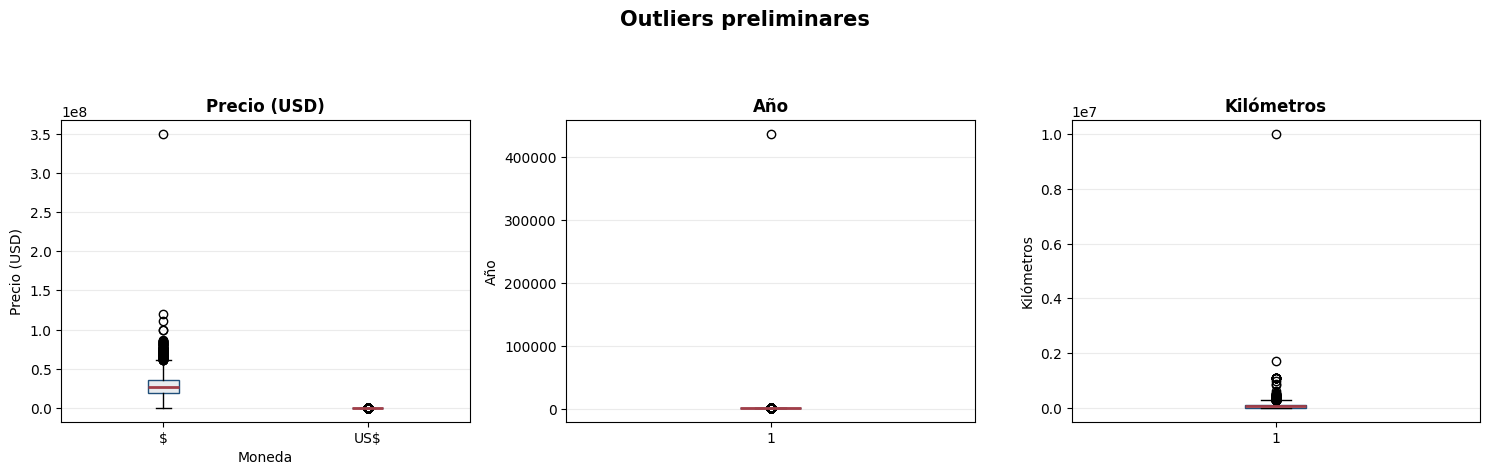

In [154]:
visual.plot_preliminary_outliers(dataset)

#### Análisis del gráfico
Los boxplots permiten identificar la presencia de valores atípicos y posibles errores de carga en las variables numéricas. En `Precio` y `Kilómetros` se observan algunos valores extremadamente elevados en comparación con la mayor parte de las observaciones, generando distribuciones con colas largas. Además, `Año` presenta al menos un valor claramente imposible, muy superior al año actual, lo que indica un error de registro

<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [155]:
dataset_processed = prep.drop_irrelevant_columns(dataset.copy(), columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [156]:
constant_columns = eda.get_constant_columns(dataset_processed)
constant_columns

,column,unique_value
0,Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [157]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

In [158]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


El chequeo muestra que existe una observación con un valor de **`Año`** igual a **436694**, lo cual no es interpretable como año de fabricación del vehículo.

Además, la variable **`Puertas`** presenta un valor máximo de **60252**, y se detectan observaciones con más de 5 puertas. Dado que estos valores no son razonables para vehículos SUV, se consideran inconsistencias del dataset y se eliminan antes del entrenamiento de los modelos.

In [159]:
range_rules = {
    "Año": {"max": 2025},
    "Puertas": {"max": 5},
}

dataset_processed = prep.remove_invalid_values(dataset_processed, range_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en una misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares estadounidenses, se convierten los precios publicados en pesos a USD.

El dataset fue construido entre el 13/05/2025 y el 30/05/2025. Por este motivo, se utiliza como tipo de cambio el promedio de la cotización diaria del dólar oficial vendedor del Banco Nación durante ese período.

In [160]:
official_usd_sell = {
    "2025-05-13": 1150.00,
    "2025-05-14": 1150.00,
    "2025-05-15": 1150.00,
    "2025-05-16": 1160.00,
    "2025-05-19": 1155.00,
    "2025-05-20": 1160.00,
    "2025-05-21": 1160.00,
    "2025-05-22": 1155.00,
    "2025-05-23": 1150.00,
    "2025-05-26": 1160.00,
    "2025-05-27": 1170.00,
    "2025-05-28": 1175.00,
    "2025-05-29": 1195.00,
    "2025-05-30": 1195.00,
}

In [161]:
EXCHANGE_RATE = sum(official_usd_sell.values()) / len(official_usd_sell)
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE:.2f}")

El tipo de cambio utilizado es de $1163.21


In [162]:
dataset_processed = prep.convert_peso_prices_to_usd(dataset_processed, EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Kilometers to int
</div>

Como se observó, la columna **`Kilómetros`** fue cargada con tipo `object`, por lo que hay que convertirla a float, teniendo en cuenta que algunos valores incluyen la unidad "km", la cual será eliminada

In [163]:
dataset_processed["Kilómetros"] = (
    dataset_processed["Kilómetros"]
    .apply(prep.extract_first_integer)
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta etapa se aplican los reemplazos necesarios para estandarizar las variables categóricas identificadas previamente. Para ello, primero cada valor se normaliza mediante `normalize_category_text`, que transforma el texto a minúsculas, elimina tildes y homogeniza separadores y espacios. Luego, `apply_semantic_mapping` reemplaza cada variante por una categoría final definida manualmente mediante diccionarios de mapeo.

Los mapas de reemplazo se construyeron únicamente para aquellos casos en los que la equivalencia semántica era clara, evitando agrupar categorías que, aunque similares en su escritura, representan conceptos diferentes.

Además, los valores faltantes se mantienen como la categoría explícita `missing`. De esta manera, la ausencia de información se conserva como una señal potencialmente informativa para el modelo, en lugar de perderse durante las etapas posteriores de codificación

In [164]:
BRAND_MAP = {
    "renault": ["renault", "rrenault"],
    "hyundai": ["hiunday", "hyundai"],
    "volkswagen": ["volkswagen", "vol"],
    "ds": ["ds", "d.s.", "d·s", "ds automobiles"],
    "land rover": ["range rover", "land rover"],
    "great wall motor": ["gwm", "haval"],
    "volkswagen": ["volkswagen", "vol"],
    "otros": ["alfa romeo", "jac", "jetour", "jetur", "isuzu", "lifan", "lexus", 
              "subaru", "daihatsu", "mini", "kaiyi", "jaguar",],
}

MODEL_MAP = {
    "sw4": ["sw4", "hilux sw4"],
    "ds7": ["ds7", "ds7 crossback"],
    "clase ml": ["clase ml", "ml"],
    "santa fe": ["santa fe", "grand santa fe", "grand santa fé"],
    "tiggo 4": ["tiggo 4", "tiggo 4 pro"],
}

COLOR_MAP = {
    "blanco": ["blanca", "blanco", "blanco glaciar", "summit white", "mineralweiss metallic", "blanco nacre tricapa", "blanco banquise"],
    "negro": ["negra", "negro", "carbon black", "black meet kettle", "noir perla nera"],
    "amarillo": ["amarilla", "amarillo", "amarrillo"],
    "dorado": ["dorada", "dorado", "champaing"],
    "gris": ["gris", "gris plata", "gris platino", "plata", "plateado", "gray", "gris laque", "plata bari", "prata bari+tet vulc", "gris estrella", "gris artense"],
    "gris oscuro": ["gris oscuro", "gris selenium", "grafito", "granite crystal bc", "granite crysta bc", "gris titane", "gris indy", "gris silverstone", "skyscraper grau metallic"],
    "marron": ["marron claro", "marron oscuro", "cafe", "marron kodiak"],
    "azul": ["azul", "steel blue", "blue"],
    "rojo": ["rojo", "rojo sunset metalizado"],
    "verde": ["verde", "verde oscuro"],
    "beige": ["beige", "beige techo negro"],
    "celeste": ["celeste", "azul claro"],
    "naranja": ["naranja", "cobre"],
    "violeta": ["violeta", "morado", "morado oscuro"],
    "bordo": ["bordo"],
    "otros": ["otro", "acero", "rosa", "moundaz", "cendre", "blanco banchisa bicolor negro"]
}

FUEL_TYPE_MAP = {
    "hibrido ": ["hibrido", "hibrido/nafta"]
}

TRANSMISSION_MAP = {
    "automatica ": ["automática", "automatica", "automatica secuencial", "automática secuencial", "semiautomatica", "semiautomática"]
}


In [165]:
dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Marca", 
                                               category_map = BRAND_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Modelo", 
                                               category_map = MODEL_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Color", 
                                               category_map = COLOR_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Tipo de combustible", 
                                               category_map = FUEL_TYPE_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Transmisión", 
                                               category_map = TRANSMISSION_MAP)

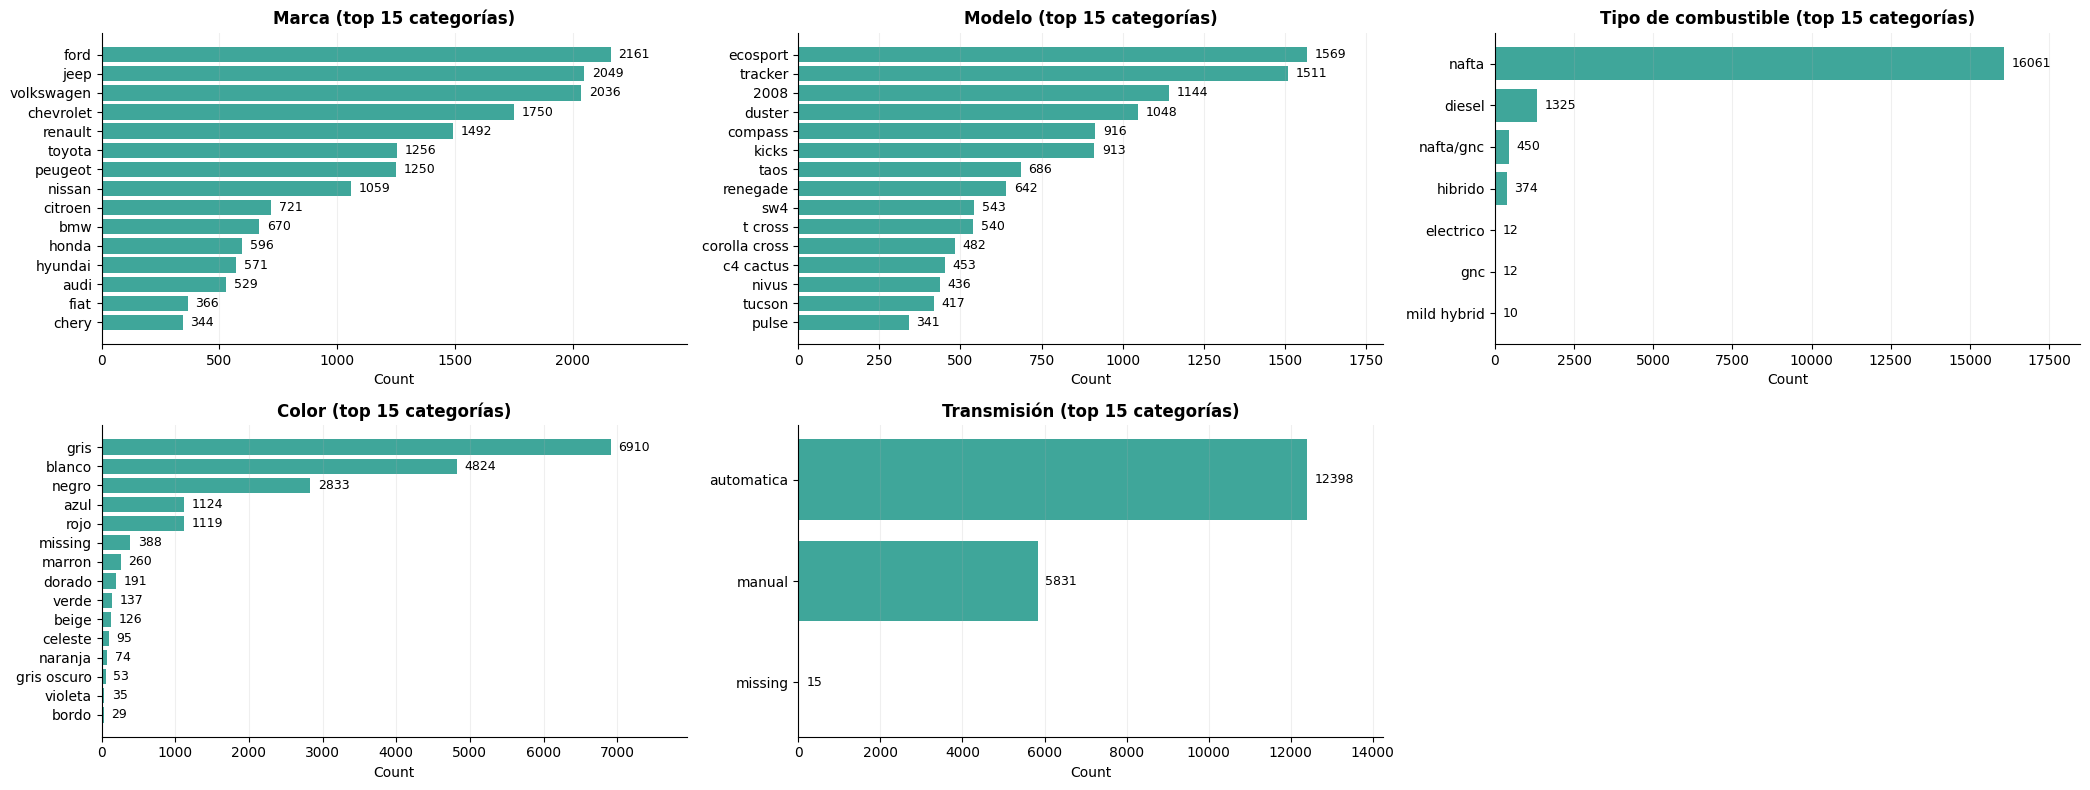

In [166]:
categorical_columns_to_check = [
    "Marca",
    "Modelo",
    "Tipo de combustible",
    "Color",
    "Transmisión",
]

visual.plot_compact_value_counts(
    dataset_processed,
    columns=categorical_columns_to_check,
    top_n=15,
    n_cols=3
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Algunas variables categóricas representan información binaria, es decir, valores de tipo **sí/no**. Para que puedan ser utilizadas por los modelos predictivos, estas variables deben transformarse a una representación numérica.

En este caso, la variable **`Con cámara de retroceso`** se codifica como:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [167]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = prep.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Value Handling
</div>

En esta sección se revisan algunos valores faltantes que pueden recuperarse a partir de información textual disponible en otras columnas del dataset, principalmente `Título`, `Descripción` y `Versión`.

No se imputan todos los valores faltantes, sino únicamente aquellos casos en los que el texto contiene una señal explícita y suficientemente clara. Para variables categóricas, como `Color` y `Transmisión`, primero se buscan menciones de categorías conocidas luego de aplicar la misma normalización semántica usada en la limpieza previa. Si se detecta una única categoría, el valor se completa; si aparecen varias categorías posibles, el caso se mantiene sin imputar para evitar asignaciones ambiguas.

Para variables con una estructura más específica, como `Motor` o `Con cámara de retroceso`, se usan extractores diseñados para detectar patrones concretos dentro del texto. En `Motor`, se buscan valores de cilindrada y señales de turbo. En `Con cámara de retroceso`, solo se completa el valor cuando aparece una mención explícita de la cámara.

Este criterio permite recuperar información que ya estaba presente en la publicación sin introducir imputaciones estadísticas todavía. Los valores que no puedan recuperarse con suficiente confianza se mantienen como faltantes o como categoría `missing`, y se revisan más adelante según su relevancia para el modelado.

### Color
Se buscan menciones de colores en las columnas de texto y se completan únicamente los casos con una sola categoría detectada.

In [168]:
color_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Color",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=COLOR_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

color_row_mentions

,row_index,Color_is_missing,matched_categories,n_category_mentions
0,4407,True,azul,1
1,4476,True,blanco | negro,2
2,6776,True,gris,1
3,8804,True,beige,1
4,10789,True,blanco | negro,2
5,10884,True,azul,1
6,11095,True,blanco | gris | gris oscuro | negro,4
7,11460,True,blanco | negro,2
8,13138,True,negro,1
9,13220,True,gris | negro,4


In [169]:
dataset_processed, color_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Color",
    matches_df=color_row_mentions,
)

color_fill_audit

Missing rows in 'Color': 388
Filled from text matches: 8
Still missing after text matches search: 380


,row_index,matched_categories,n_unique_matches,fill_value,target_col
85,4407,azul,1.0,azul,Color
141,6776,gris,1.0,gris,Color
173,8804,beige,1.0,beige,Color
216,10884,azul,1.0,azul,Color
269,13138,negro,1.0,negro,Color
315,14804,blanco,1.0,blanco,Color
325,15343,gris,1.0,gris,Color
353,16483,blanco,1.0,blanco,Color


### Motor
Se extrae información de cilindrada desde el texto y se conserva la señal de turbo cuando aparece explícitamente.

In [170]:
ENGINE_TEXT_MAP = {
    "1.0": [
        "1.0",
        "1.0t",
        "1.0 t",
        "1.0 tsi",
        "1.0 200 tsi",
    ],
    "1.3": [
        "1.3",
        "1.3 tce",
        "1.3 tce turbo",
        "1.3 t270",
    ],
    "1.5": [
        "1.5",
        "1.5t",
        "1.5 t",
        "1.5 turbo",
    ],
    "1.6": [
        "1.6",
        "1.6l",
        "1.6 16v",
        "1.6 vti",
        "1.6 thp",
    ],
    "1.8": [
        "1.8",
    ],
    "2.0": [
        "2.0",
        "2.0 sport",
        "2.0 sel",
        "2.0 hse",
        "2.0 turbo",
        "2.0 turbonaftero",
    ],
    "2.5": [
        "2.5",
    ],
    "2.8": [
        "2.8",
    ],
}

In [171]:
engine_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=ENGINE_TEXT_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

engine_row_mentions

,row_index,Motor_is_missing,matched_categories,n_category_mentions
0,209,True,2.5,2
1,219,True,1.0,4
2,2488,True,1.6,2
3,2764,True,1.8,3
4,3624,True,1.5,6
5,3760,True,1.6,4
6,4418,True,1.6,4
7,6095,True,1.5,3
8,7915,True,1.5,2
9,8264,True,1.0,2


In [172]:
dataset_processed, engine_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Versión", "Título", "Descripción"),
    extractor=prep.extract_engine_liters_from_text,
    extracted_col_name="extracted_engine",
)

engine_audit.head(10)

Missing rows in 'Motor': 38
Filled from text: 21
Still missing after text search: 17


,row_index,text_used,extracted_engine,was_missing,was_filled
0,209,4X2 Hibrida AT Ford Kuga 2.5 Hibrida 4x2 At 2...,2.5,True,True
1,219,1.0 200 Tsi Highline Tip Volkswagen T-Cross 1...,1.0 turbo,True,True
2,2488,1.6 S 110cv 4x2 Ford Ecosport 1.6 S 110cv 4x2...,1.6,True,True
3,2764,1.8 4x2 Sport Jeep Renegade 1.8 4x2 Sport Som...,1.8,True,True
4,3624,1.5 Turbo LX 4x2 Honda Cr-v 1.5 Turbo Lx 4x2 ...,1.5 turbo,True,True
5,3760,1.6 Thp 165 At6 Shine Citroën C4 Cactus 1.6 T...,1.6 turbo,True,True
6,4418,1.6 Vti 115 X-series Citroën C4 Cactus 1.6 Vt...,1.6,True,True
7,6095,1.5t Titanium Ford Territory 1.5t Titanium Us...,1.5,True,True
8,7915,1.5t Titanium Ford Territory 1.5t Titanium De...,1.5,True,True
9,8264,1.0T Gt Peugeot 2008 1.0t Gt El vendedor no i...,1.0,True,True


### Transmisión
Se buscan variantes textuales de transmisión manual o automática y se imputan solo los casos no ambiguos.

In [173]:
TRANSMISSION_MAP_TEXT = {
    "automatica": [
        "automatica",
        "automatico",
        "caja automatica",
        "at",
        "at6",
        "at8",
        "at9",
        "cvt",
        "dsg",
        "tiptronic",
        "secuencial",
    ],
    "manual": [
        "manual",
        "caja manual",
        "mt",
    ],
}

In [174]:
transmission_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Transmisión",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=TRANSMISSION_MAP_TEXT,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

transmission_row_mentions

,row_index,Transmisión_is_missing,matched_categories,n_category_mentions
0,2194,True,automatica,2
1,5507,True,automatica,2
2,7663,True,automatica,4
3,12920,True,automatica,2
4,12979,True,automatica,2
5,17594,True,automatica,4
6,17665,True,automatica | manual,8


In [175]:
dataset_processed, transmission_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Transmisión",
    matches_df=transmission_row_mentions,
)

transmission_fill_audit

Missing rows in 'Transmisión': 15
Filled from text matches: 6
Still missing after text matches search: 9


,row_index,matched_categories,n_unique_matches,fill_value,target_col
1,2194,automatica,1.0,automatica,Transmisión
2,5507,automatica,1.0,automatica,Transmisión
5,7663,automatica,1.0,automatica,Transmisión
10,12920,automatica,1.0,automatica,Transmisión
11,12979,automatica,1.0,automatica,Transmisión
13,17594,automatica,1.0,automatica,Transmisión


### Con cámara de retroceso

Se completa la variable únicamente cuando el texto menciona explícitamente la presencia de cámara de retroceso.

In [176]:
CAMARA_MAP = {
    "Camara de retroceso": ["Cámara de retroceso", "Camara de retroceso"]
}

In [177]:
camera_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=CAMARA_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

camera_row_mentions.head(30)

,row_index,Con cámara de retroceso_is_missing,matched_categories,n_category_mentions
0,4,True,camara de retroceso,1
1,45,True,camara de retroceso,1
2,54,True,camara de retroceso,1
3,175,True,camara de retroceso,1
4,269,True,camara de retroceso,1
5,276,True,camara de retroceso,1
6,292,True,camara de retroceso,1
7,435,True,camara de retroceso,1
8,446,True,camara de retroceso,1
9,541,True,camara de retroceso,1


In [178]:
dataset_processed, camera_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    extractor=prep.extract_backup_camera,
    extracted_col_name="extracted_camera",
)

camera_audit.head(10)

Missing rows in 'Con cámara de retroceso': 13556
Filled from text: 486
Still missing after text search: 13070


,row_index,text_used,extracted_camera,was_missing,was_filled
0,4,Jeep Compass 2.4 Sport At •Unico dueño•Todos ...,1.0,True,True
1,36,Mercedes-Benz Clase GLE GLE 450 4MATIC (MHEV)...,1.0,True,True
2,45,Kia Sorento 2.5 Ex Crdi 170 Hp At Kia sorento...,1.0,True,True
3,54,Toyota RAV4 2.5 4x4 6at TOYOTA RAV4 VX 2.5l 4...,1.0,True,True
4,86,BMW X3 2.0 Xdrive 30E Xline Descripción!!!!De...,1.0,True,True
5,155,Audi Q3 1.4 Tfsi Stronic 150 Cv Audi Q3 35 TF...,1.0,True,True
6,175,Chery Tiggo 2.0 F2 Confort 4x2 138cv Chery Ti...,1.0,True,True
7,225,Toyota Corolla Cross 2.0 Seg Cvt Toyota Corol...,1.0,True,True
8,230,Chevrolet Equinox 1.5t Premier 4wd CHEVROLET ...,1.0,True,True
9,269,Jeep Commander 1.3 T270 Limited 4X2 At6 ANTIC...,1.0,True,True


# REVISAR

In [179]:
dataset_processed, camera_imputation_audit = prep.impute_backup_camera_by_brand_model_year(
    dataset_processed
)

Missing rows in 'Con cámara de retroceso': 13070
Filled from group consensus: 4299
Still missing after group consensus search: 8771


# ----

Ahora bien, aquellos faltantes que corresponden a autos fabricados antes del año 2000 
podemos asumirlos como 0, ya que la cámara de retroceso no era una tecnología 
disponible en esa época.

In [180]:
dataset_processed = prep.impute_missing_by_year(dataset_processed, "Con cámara de retroceso", year_threshold = 2000)

Filled 103 rows in 'Con cámara de retroceso' with 0 (older than 2000)


KNN: si el KNN usa información de features para imputar, lo ideal metodológicamente es ajustarlo solo con train y aplicarlo luego a test, para evitar leakage.

In [181]:
dataset_processed, camera_knn_audit = knn.impute_missing_knn(
    dataset_processed,
    target_col="Con cámara de retroceso",
    feature_cols=["Año", "Kilómetros", "Precio"],
    n_neighbors=5,
    round_result=True,
    clip_range=(0, 1),
)

Missing rows in 'Con cámara de retroceso': 8668
Filled with KNN: 8668


### Checking updated dataset

In [182]:
# Previous missing values
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13563,74.30
1,Color,389,2.13
2,Motor,38,0.21
3,Transmisión,15,0.08


In [183]:
# Current missing values
eda.missing_values_summary(dataset_processed)

,column,missing_count,missing_percentage
0,Color,380,2.08
1,Motor,17,0.09
2,Transmisión,9,0.05


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
New Columns to Represent Engine Feature
</div>

Para la variable `Motor`, se busca extraer información técnica que aparece escrita de distintas formas en el texto original. En particular, se recupera la cilindrada del motor y se conserva la presencia de turbo cuando esta información aparece explícitamente mencionada.

Ya se completaron algunos valores faltantes de `Motor` utilizando las columnas `Título`, `Descripción` y `Versión`. Para esto se identifican patrones confiables de cilindrada, como `1.6`, `2.0`, `1.5t`, `1.3 TCE`, `1.0 TSI` o valores en centímetros cúbicos como `1600 cc`. Cuando además se detectan expresiones asociadas a turbo, como `turbo`, `TSI`, `TDI`, `THP` o `TCE`, el valor imputado conservó esa información en el texto, por ejemplo `1.5 turbo`.

Luego, a partir de la columna `Motor` ya completada, se crean nuevas variables. La columna `Cilindrada` almacena la cilindrada extraída en litros como valor numérico, mientras que `Tiene turbo` indica si el motor presenta señales de turbo en el texto. Además, se genera `Grupo cilindrada`, una variable ordinal que resume la cilindrada en rangos ordenados para facilitar su uso posterior en análisis y modelado.

De esta forma, la información técnica contenida originalmente en `Motor` queda representada en columnas más limpias y comparables. Una vez creadas estas variables derivadas, la columna original `Motor` puede eliminarse del dataset final.

In [184]:
TURBO = [
    "turbo",
    "turboalimentado",
    "tsi",
    "tdi",
    "tfsi",
    "ecoboost",
    "tce",
    "thp",
    r"\bt\b", # Match 't' as a whole word
    r"\d\.\d\s*t\b", # Match patterns like '1.6 T'
]

In [185]:
dataset_processed["Cilindrada"] = dataset_processed["Motor"].apply(prep.extract_engine_liters)
dataset_processed["Cilindrada"].isna().sum()

np.int64(311)

Algunas columas de `Motor` solo decian cosas como "Turboalimentado", por lo que tienen NAN a la hora de completar la cilindrada. Esos valores los podemos recuperar de las columnas `Versión` y `Descripción`

In [186]:
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Versión"].apply(prep.extract_engine_liters)
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Descripción"].apply(prep.extract_engine_liters)

In [187]:
print(dataset_processed["Cilindrada"].isna().sum())
print(dataset_processed["Cilindrada"].head())

22
0    1.5
1    2.0
2    1.4
3    1.5
4    2.4
Name: Cilindrada, dtype: float64


In [188]:
dataset_processed["Grupo cilindrada"] = dataset_processed["Cilindrada"].apply(prep.encode_engine_size)
dataset_processed["Tiene turbo"] = dataset_processed["Motor"].apply(lambda value: prep.has_turbo(value, turbo_patterns = TURBO))

In [189]:
# Deleting Motor column as it has been processed into new features
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Motor"])

In [190]:
print(dataset_processed["Grupo cilindrada"].value_counts())
print(dataset_processed["Grupo cilindrada"].isna().sum())

Grupo cilindrada
2    7412
3    5057
1    2462
4    2061
5    1230
0      22
Name: count, dtype: int64
0


In [191]:
dataset_processed["Tiene turbo"].value_counts()

Tiene turbo
0    17874
1      370
Name: count, dtype: int64

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Text-Based Condition Features
</div>

Las columnas `Título`, `Descripción` y `Versión` tienen bastante información escrita por los vendedores. Parte de esa información ya la usamos para completar valores faltantes, como `Color`, `Motor`, `Transmisión` o `Con cámara de retroceso`.

Antes de eliminar estas columnas, se busca rescatar algunas señales simples que pueden ser útiles para predecir el precio. En vez de aplicar un modelo de NLP más complejo, se define un conjunto de palabras y frases de interés y se crean variables binarias que indiquen si esas expresiones aparecen o no en la publicación.

In [192]:
eda.frequent_words_table(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    top_n=50
)

,word,count
0,000,7497
1,4x2,6118
2,cvt,4754
3,usado,4502
4,jeep,4004
5,volkswagen,3913
6,estado,3893
7,tsi,3851
8,usados,3845
9,4x4,3840


Teniendo un paneo general de las palabras más frecuengtes, vemos hay gran variedad de tipos de palabra. Muchas de estas están relacionadas al auto como producto, pero no hablan mucho del estado. Por eso, podríamos buscar la frecuencia de palabras agrupadas según el tipo de información que representan. Por ejemplo, algunas expresiones hacen referencia a documentación o papeles al día, otras a services o mantenimiento, otras al buen estado del vehículo, y otras a posibles detalles o daños. Vamos a gregar columnas binarias que representen estas condiciones.

Tambien, agregaremos una columna para identificar las publicaciones en las que no aparece ninguna de estas señales. Esto permite diferenciar entre autos con alguna información textual relevante y publicaciones donde el texto no aporta demasiado en este sentido.

In [193]:
INTEREST_TERMS = {
    "papeles": [
        "papeles al dia",
        "documentacion al dia",
        "documentacion en regla",
        "listo para transferir",
        "lista para transferir",
        "sin deudas",
        "libre deuda",
        "libre de deuda",
        "vtv",
        "verificacion policial",
    ],
    "service": [
        "service",
        "services",
        "service oficial",
        "services oficiales",
        "mantenimiento",
        "distribucion hecha",
        "bateria nueva",
        "cubiertas nuevas",
    ],
    "buen_estado": [
        "buen estado",
        "muy buen estado",
        "excelente estado",
        "excelentes condiciones",
        "buenas condiciones",
    ],
    "impecable": [
        "impecable",
        "impecables",
        "sin detalles",
        "como nuevo",
        "como nueva",
        "como 0km",
    ],
    "cuidado": [
        "cuidado",
        "cuidada",
        "muy cuidado",
        "muy cuidada",
        "bien cuidado",
        "bien cuidada",
    ],
    "detalles_uso": [
        "detalles de uso",
        "detalle de uso",
        "detalles esteticos",
        "detalle estetico",
    ],
    "daño": [
        "rayado",
        "rayada",
        "rayones",
        "golpe",
        "golpes",
        "golpeado",
        "golpeada",
        "abollado",
        "abollada",
        "abolladura",
    ],
    "sin_choque": [
        "sin choque",
        "sin choques",
        "nunca chocado",
        "nunca chocada",
    ],
}

In [194]:
eda.count_interest_terms_in_text(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    terms_map=INTEREST_TERMS,
)

,term,count,row_count
0,papeles,3819,2842
1,service,3503,2611
2,buen_estado,2918,2299
3,impecable,1998,1748
4,cuidado,957,530
5,daño,69,65
6,detalles_uso,61,61
7,sin_choque,34,34


In [195]:
dataset_processed = prep.add_text_indicator_features(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    terms_map=INTEREST_TERMS,
    add_no_match_feature=True,
    no_match_feature_name="sin_condicion",
)

In [196]:
dataset_processed.columns

Index(['Marca', 'Modelo', 'Año', 'Versión', 'Color', 'Tipo de combustible',
       'Puertas', 'Transmisión', 'Con cámara de retroceso', 'Kilómetros',
       'Título', 'Precio', 'Descripción', 'Tipo de vendedor', 'Cilindrada',
       'Grupo cilindrada', 'Tiene turbo', 'papeles', 'service', 'buen_estado',
       'impecable', 'cuidado', 'detalles_uso', 'daño', 'sin_choque',
       'sin_condicion'],
      dtype='object')

Estas variables no dicen por sí solas si el precio debería subir o bajar. Por ejemplo, una mención a `service` o `impecable` podría estar asociada a un mejor estado del auto, mientras que una mención a `rayones` o `golpes` podría indicar lo contrario. La idea es dejar que el modelo aprenda esa relación a partir de los datos.

Una vez extraídas estas señales, las columnas originales de texto ya no se van a usar directamente, entonces las sacamos.

In [197]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed,columns_to_drop=["Título", "Descripción", "Versión"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Final Missing Value Encoding
</div>

Antes de separar el dataset y aplicar one-hot encoding, se completan los valores faltantes restantes en las variables categóricas. En lugar de eliminar estas observaciones o imputarlas con una categoría mayoritaria, se reemplaza cada faltante por una categoría explícita asociada a su columna.

Por ejemplo, un valor faltante en `Color` se reemplaza por `missing_Color`, mientras que un faltante en `Transmisión` se reemplaza por `missing_Transmisión`. Esto permite conservar la información de que el dato no estaba disponible, y deja que el modelo aprenda si esa ausencia tiene alguna relación con el precio.

In [198]:
dataset_processed = prep.fill_missing_with_value(dataset_processed)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Outliers Detection
</h3>

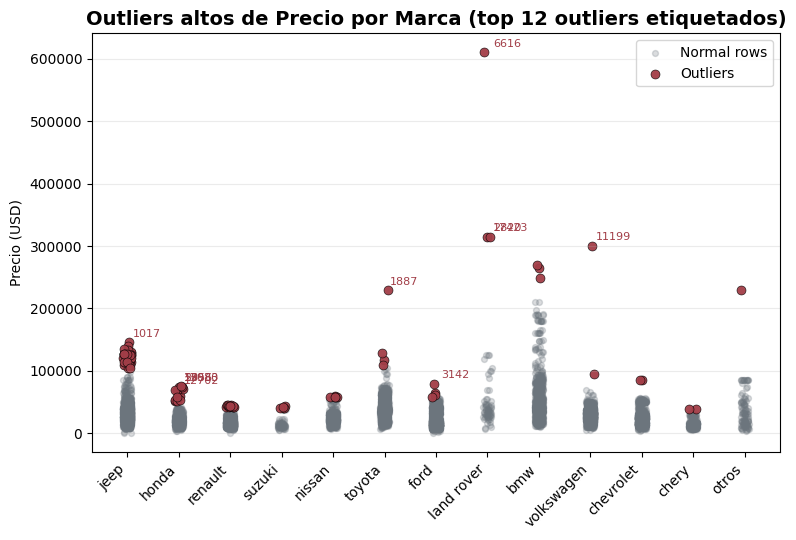

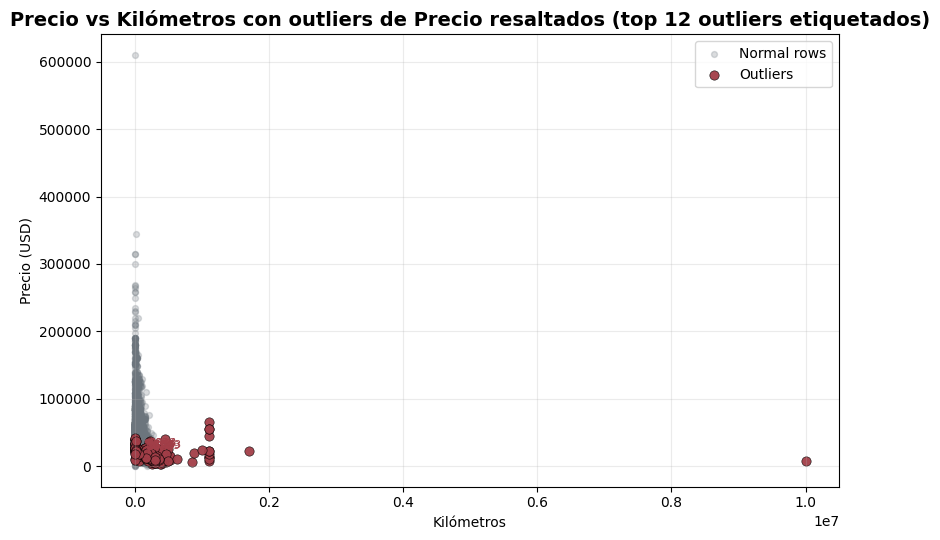

======= Price outliers =======


,row_index,Precio,Marca,lower_bound,upper_bound,iqr,outlier_type,outlier_score,Modelo,Año,...,Tiene turbo,papeles,service,buen_estado,impecable,cuidado,detalles_uso,daño,sin_choque,sin_condicion
0,11199,300460.546515,volkswagen,-14184.832668,71891.311022,9564.015966,high,23.898876,nivus,2024.0,...,0,0,0,0,0,0,0,0,0,1
1,6616,610000.000000,land rover,-65503.750000,146003.000000,23500.750000,high,19.743923,range rover sport,2024.0,...,0,0,0,0,0,0,0,0,0,1
2,1887,229000.000000,toyota,-29984.648449,104987.718760,14996.929690,high,8.269178,land cruiser,2025.0,...,0,0,0,0,0,0,0,0,0,1
3,17423,315000.000000,land rover,-65503.750000,146003.000000,23500.750000,high,7.191132,range rover sport,2025.0,...,0,0,0,0,0,0,0,0,0,1
4,2820,315000.000000,land rover,-65503.750000,146003.000000,23500.750000,high,7.191132,range rover sport,2025.0,...,0,0,0,0,0,0,0,0,0,1
5,17030,75275.000000,honda,-10470.870433,51576.696346,6894.174087,high,3.437439,cr v,2024.0,...,0,0,0,0,0,0,0,0,0,1
6,5956,74900.000000,honda,-10470.870433,51576.696346,6894.174087,high,3.383045,cr v,2024.0,...,0,0,0,0,0,0,0,0,0,1
7,13983,74900.000000,honda,-10470.870433,51576.696346,6894.174087,high,3.383045,cr v,2024.0,...,0,0,0,0,0,0,0,0,0,1
8,28,74900.000000,honda,-10470.870433,51576.696346,6894.174087,high,3.383045,cr v,2024.0,...,0,0,0,0,0,0,0,0,0,1
9,1017,146002.000000,jeep,-38275.253301,100719.066626,15443.813325,high,2.932108,grand cherokee,2024.0,...,0,0,0,0,0,0,0,0,0,1


======= Kilómetros outliers =======


,row_index,Kilómetros,Marca,lower_bound,upper_bound,iqr,outlier_type,outlier_score,Modelo,Año,...,Tiene turbo,papeles,service,buen_estado,impecable,cuidado,detalles_uso,daño,sin_choque,sin_condicion
0,9014,116000,baic,0.0,0.0,0.0,high,116000.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
1,6638,116000,baic,0.0,0.0,0.0,high,116000.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
2,15393,102000,baic,0.0,0.0,0.0,high,102000.0,x55,2019.0,...,0,0,0,0,0,0,0,0,0,1
3,5305,102000,baic,0.0,0.0,0.0,high,102000.0,x55,2019.0,...,0,0,0,0,0,0,0,0,0,1
4,1736,99800,baic,0.0,0.0,0.0,high,99800.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
5,5506,99800,baic,0.0,0.0,0.0,high,99800.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
6,16529,89000,baic,0.0,0.0,0.0,high,89000.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
7,2756,89000,baic,0.0,0.0,0.0,high,89000.0,x55,2018.0,...,0,0,0,0,0,0,0,0,0,1
8,8667,87000,baic,0.0,0.0,0.0,high,87000.0,x35,2018.0,...,0,1,0,1,0,0,0,0,0,0
9,3625,86500,baic,0.0,0.0,0.0,high,86500.0,x35,2018.0,...,0,1,1,1,0,0,0,0,0,0


In [199]:
price_outliers = visual.plot_iqr_outliers(
    dataset_processed,
    value_col="Precio",
    group_col="Marca",
    context_cols="all",
    min_group_size=50,
    side="high",
    top_n_labels=12,
    title="Outliers altos de Precio por Marca",
    iqr_multiplier = 4.0
)

price_km_outliers = visual.plot_iqr_outlier_scatter(
    dataset_processed,
    x_col="Kilómetros",
    y_col="Precio",
    outlier_col="Kilómetros",
    group_col="Marca",
    context_cols="all",
    min_group_size=50,
    side="high",
    title="Precio vs Kilómetros con outliers de Precio resaltados",
)

print("======= Price outliers =======")
display(price_outliers.head(20))
print("======= Kilómetros outliers =======")
display(price_km_outliers.head(20))

Observamos que los outliers detectados con iqr no son del todo válidos. Autos 0km no deberían ser outliers, ni tampoco autos con precios de $USD 250.000 que refieren a marcas de alta gama. Por este motivo, utilizaremos un rango definido por nosotras para delimitar los valores de estos features.

In [200]:
rules = {
"Precio":{"method": "fixed", "min": 500, "max": 400_000},
"Kilómetros":  {"method": "fixed", "min": 0,"max": 600_000},
}

# Inspect possible outliers
df_flagged = prep.detect_outliers(dataset_processed, rules, mode="flag")
df_flagged[df_flagged["is_outlier"]].head(20)

Total rows flagged as outliers (any column): 21 (0.12%)
    column method  allow_zero  lower_bound  upper_bound  outliers_found  outlier_%
    Precio  fixed       False          500       400000               4       0.02
Kilómetros  fixed       False            0       600000              17       0.09


,is_outlier,is_outlier_Precio,is_outlier_Kilómetros,Marca,Modelo,Año,Color,Tipo de combustible,Puertas,Transmisión,...,Tiene turbo,papeles,service,buen_estado,impecable,cuidado,detalles_uso,daño,sin_choque,sin_condicion
1476,True,False,True,ford,explorer,1994.0,gris,nafta,5.0,automatica,...,0,1,0,0,0,0,0,0,0,0
1852,True,False,True,ford,bronco,1981.0,marron,nafta,2.0,manual,...,0,0,0,0,0,0,0,0,0,1
2669,True,True,False,renault,duster,2025.0,gris,nafta,5.0,manual,...,0,0,0,0,0,0,0,0,0,1
5094,True,True,False,jeep,wrangler,2025.0,gris,nafta,3.0,automatica,...,0,0,0,0,0,0,0,0,0,1
6109,True,False,True,renault,duster,2013.0,negro,nafta,5.0,manual,...,0,0,0,0,0,0,0,0,0,1
6118,True,False,True,renault,duster,2018.0,negro,nafta/gnc,5.0,manual,...,0,0,0,0,0,0,0,0,0,1
6479,True,False,True,renault,duster,2013.0,blanco,nafta,5.0,manual,...,0,1,0,0,0,0,0,0,0,0
6616,True,True,False,land rover,range rover sport,2024.0,negro,nafta,5.0,automatica,...,0,0,0,0,0,0,0,0,0,1
7156,True,False,True,ford,bronco,1981.0,negro,nafta,3.0,automatica,...,0,0,0,0,0,0,0,0,0,1
7614,True,False,True,chevrolet,blazer,2000.0,verde,diesel,5.0,manual,...,0,1,1,1,0,0,0,0,0,0


In [201]:
# Deleting outliers
dataset_processed = prep.detect_outliers(dataset_processed, rules, mode="drop")
print(dataset_processed.shape)

Total rows flagged as outliers (any column): 21 (0.12%)
    column method  allow_zero  lower_bound  upper_bound  outliers_found  outlier_%
    Precio  fixed       False          500       400000               4       0.02
Kilómetros  fixed       False            0       600000              17       0.09
(18223, 23)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

Una vez terminadas las transformaciones y la recuperación de información desde texto, se separa el dataset en entrenamiento y validación (80% - 20%)

El split se realiza estratificando por `Marca`, ya que esta variable tiene una distribución desigual y suponemos    que está fuertemente relacionada con el precio. Mantener proporciones similares de marcas en train y validation ayuda a que ambos conjuntos sean más comparables.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [202]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [203]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set

In [204]:
# Split check
display(split.split_size_summary(X_train, X_val))

,split,rows,percentage
0,train,14579,80.0
1,validation,3644,20.0


In [205]:
X_train = X_train.copy()
X_val = X_val.copy()

X_train.to_csv("../data/X_train.csv", index = False)
X_val.to_csv("../data/X_val.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Pre-One Hot Analysis
</h3>

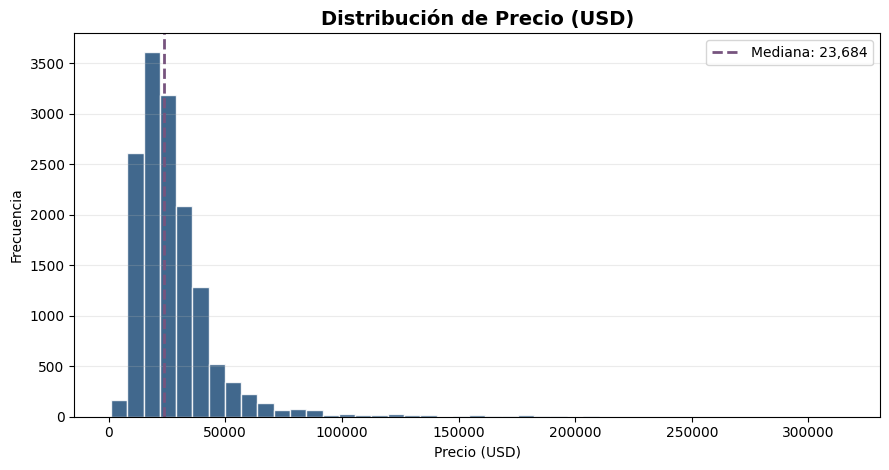

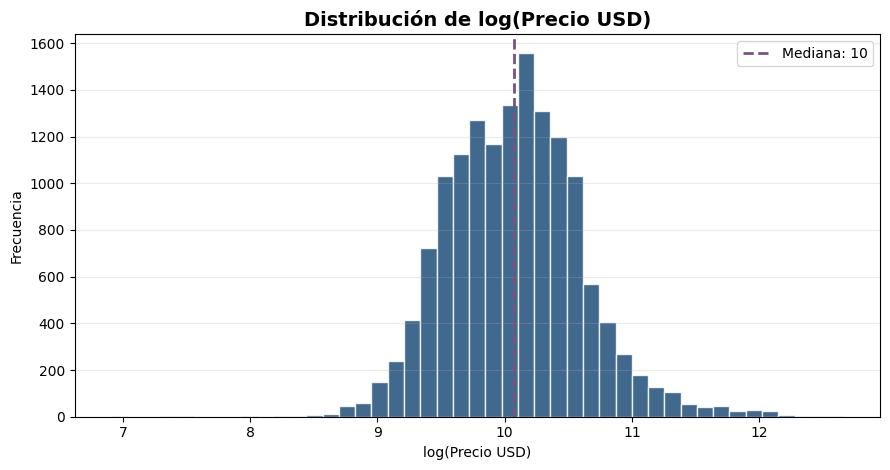

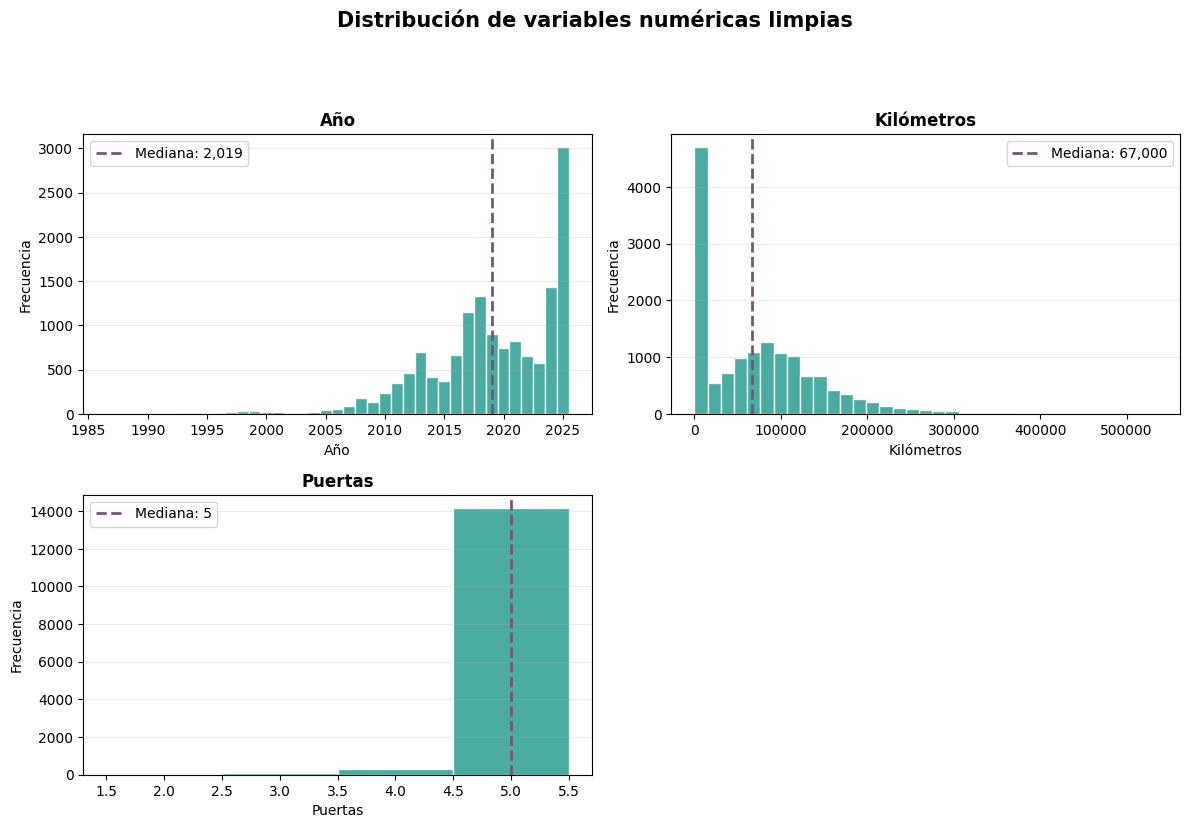

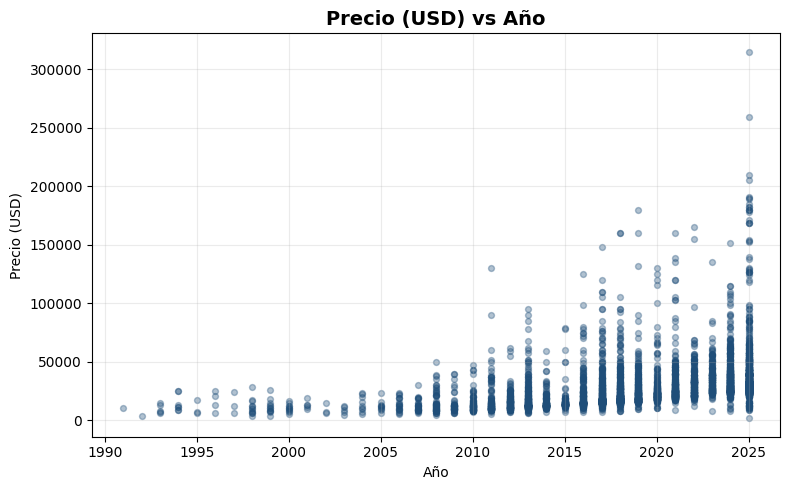

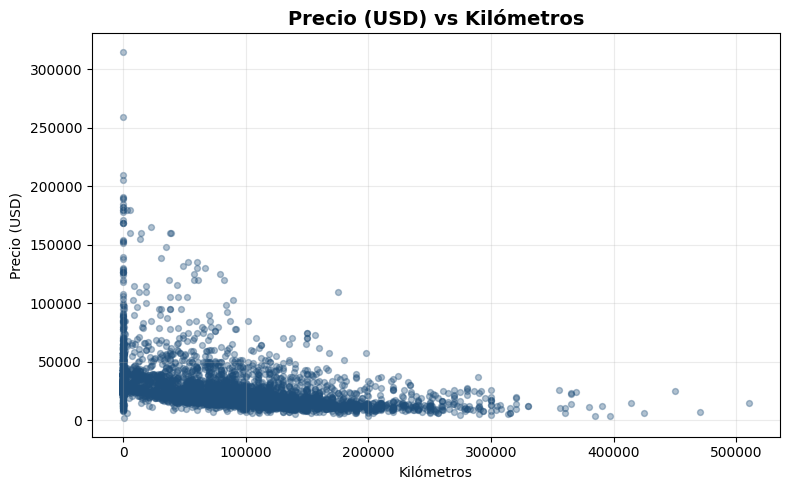

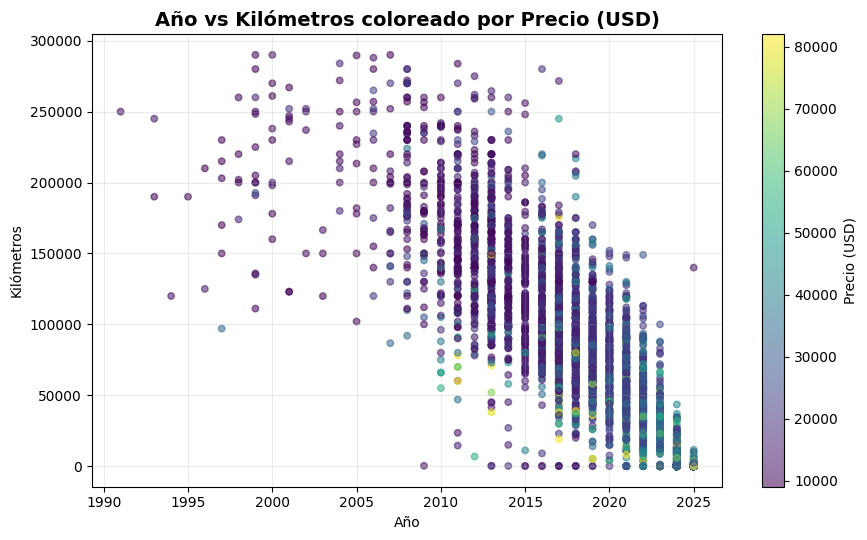

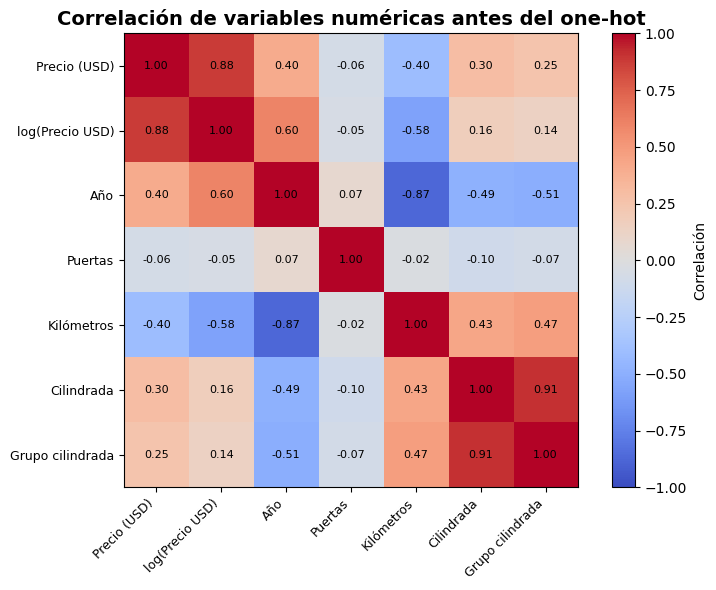

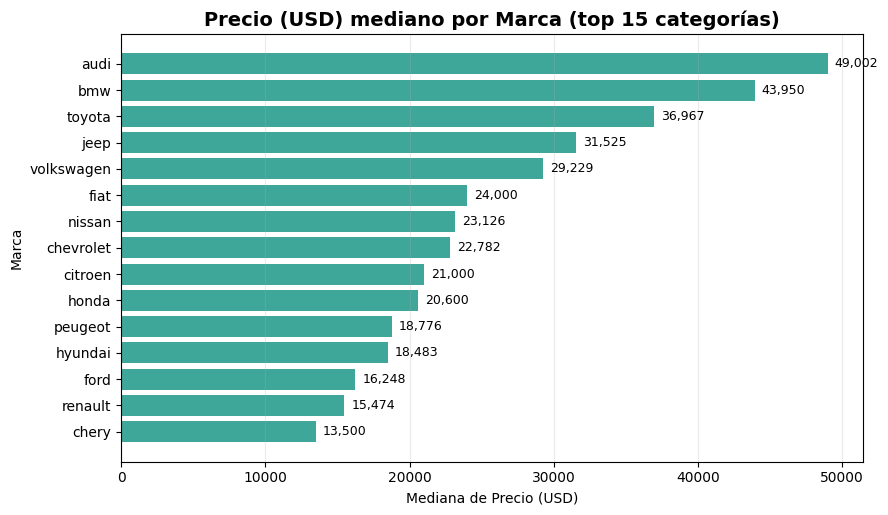

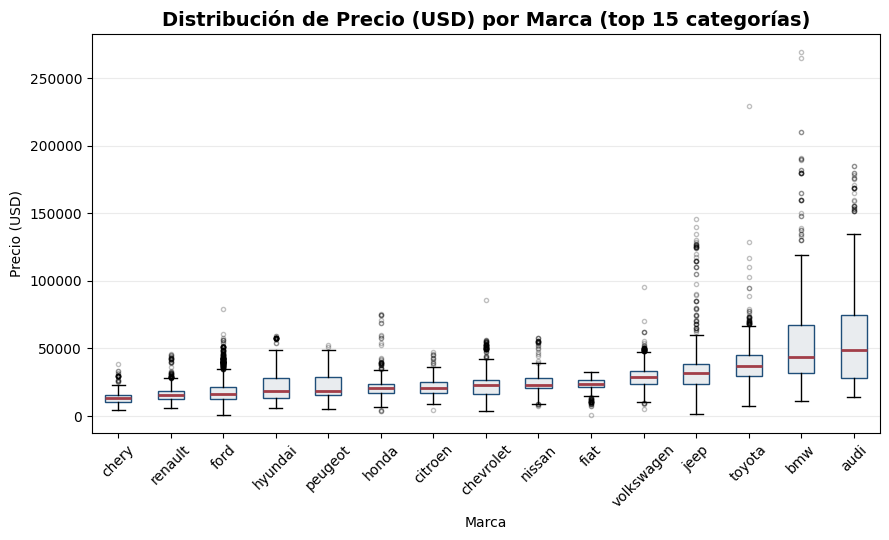

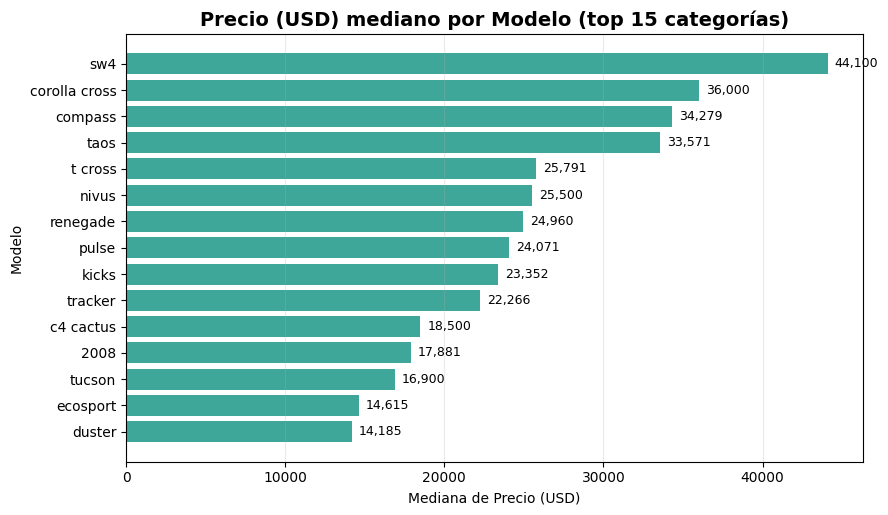

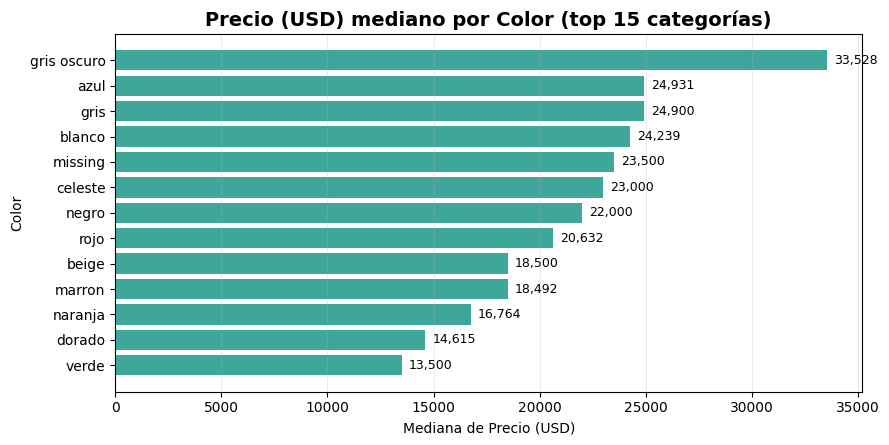

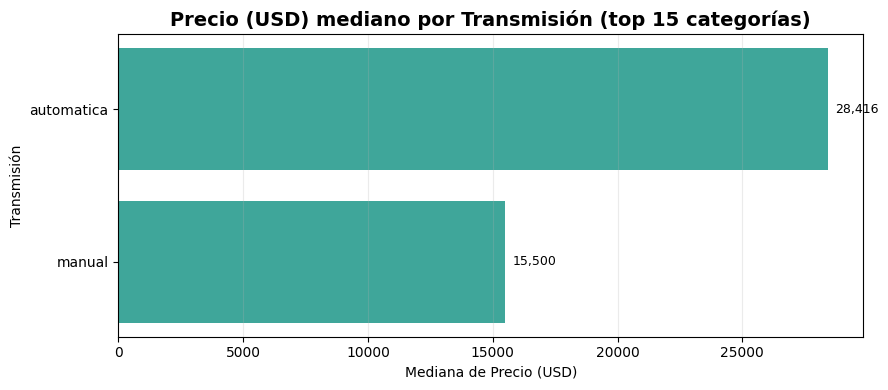

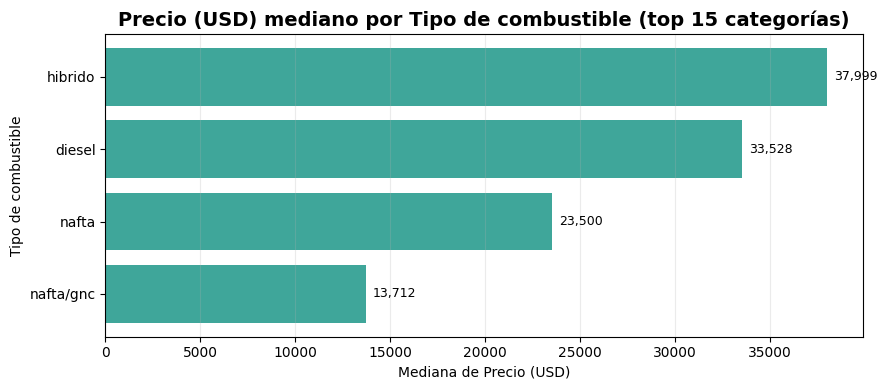

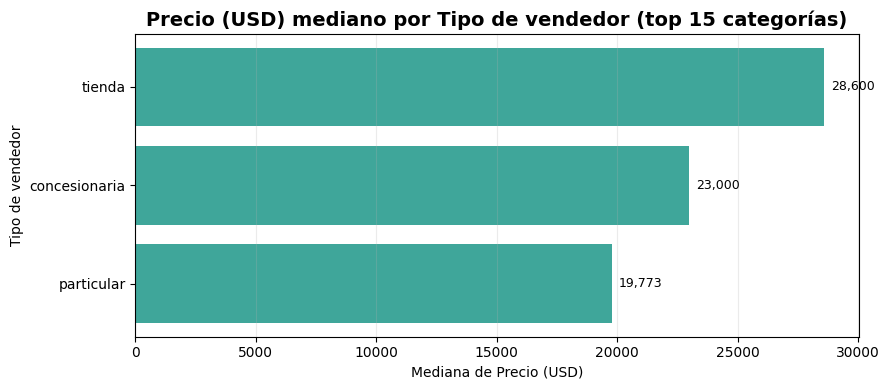

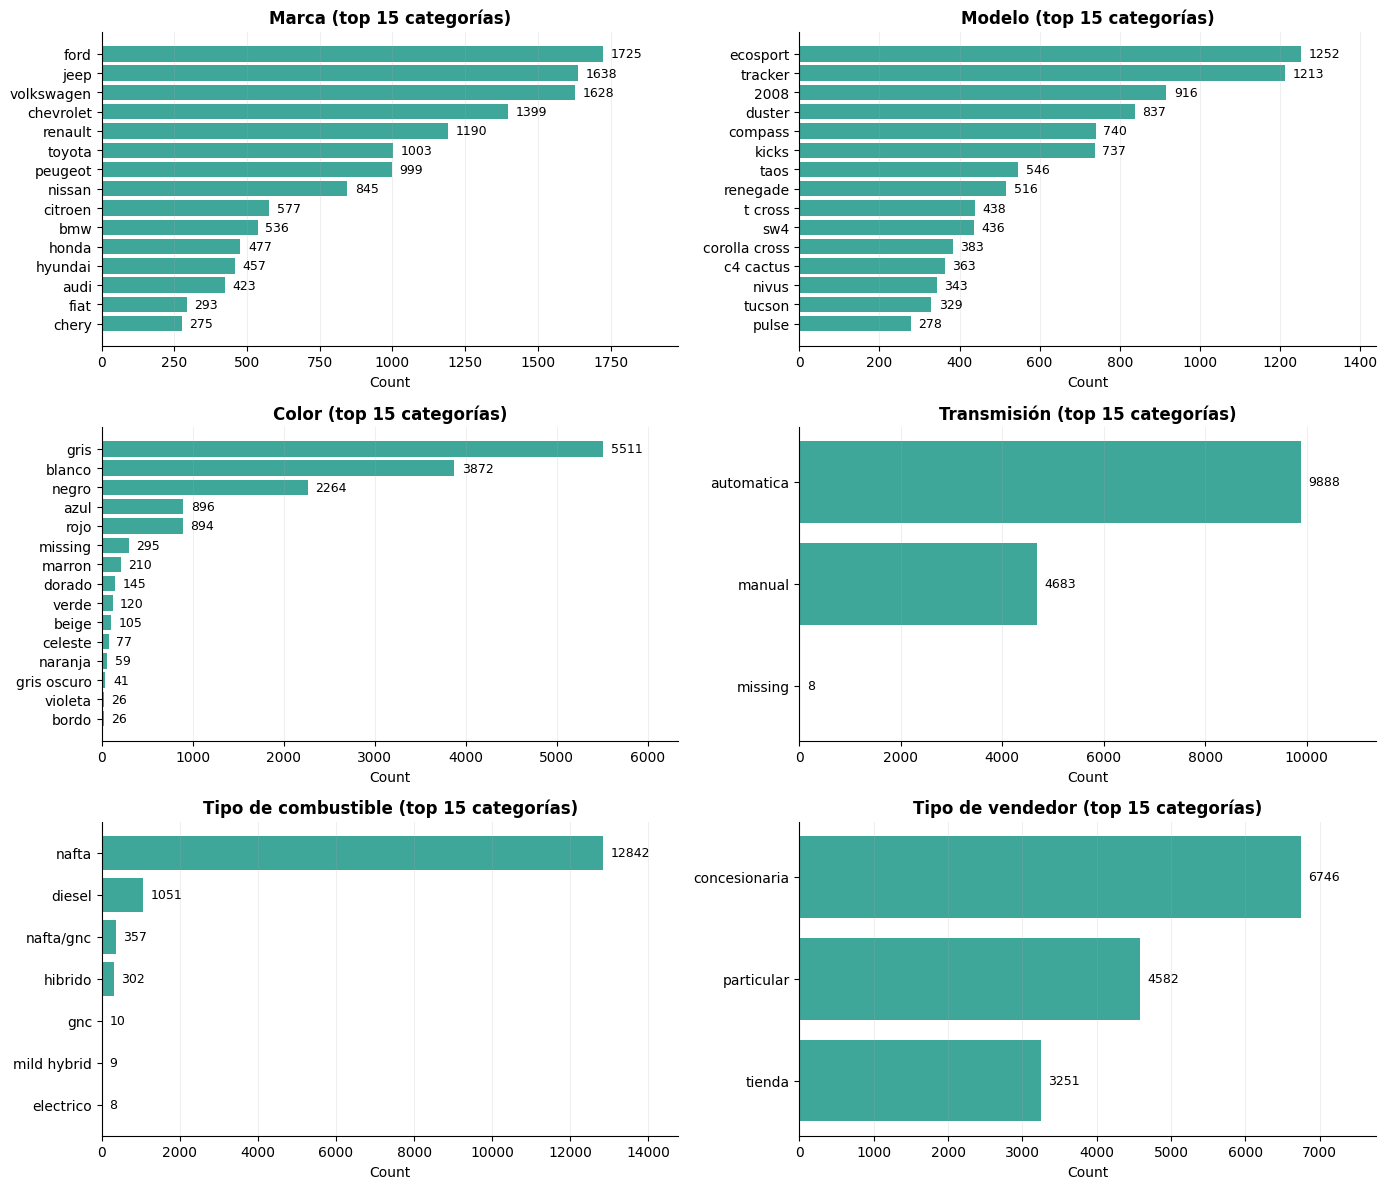

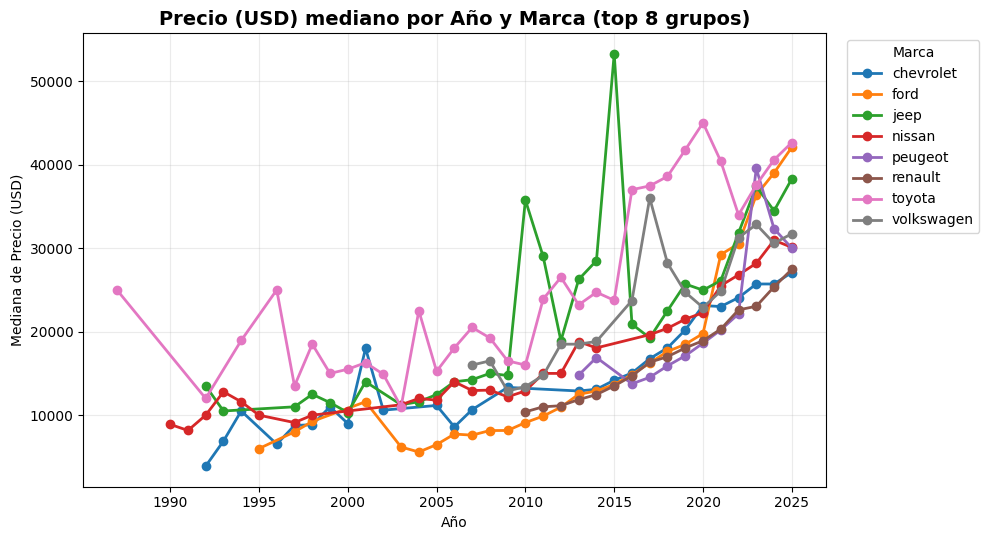

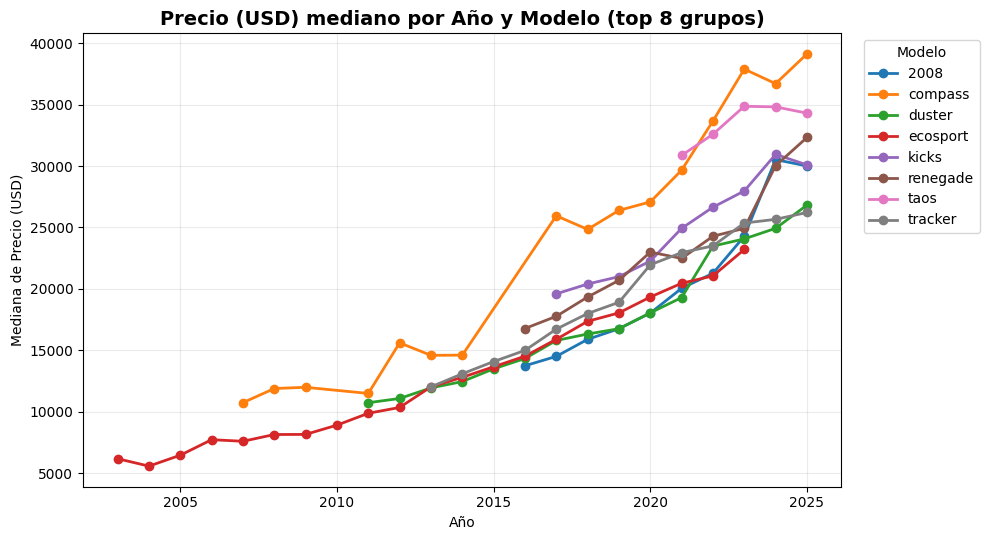

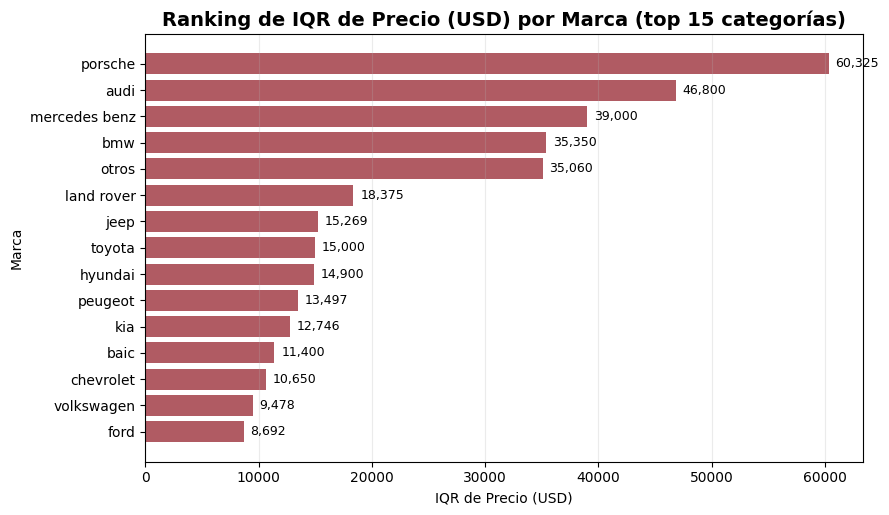

,Marca,count,q1,q3,iqr
0,porsche,54,44175.000000,104500.000000,60325.000000
1,audi,423,27900.000000,74700.000000,46800.000000
2,mercedes benz,226,30000.000000,69000.000000,39000.000000
3,bmw,536,31900.000000,67250.000000,35350.000000
4,otros,78,14614.676082,49675.000000,35060.323918
5,land rover,52,26875.000000,45250.000000,18375.000000
6,jeep,1638,23500.000000,38769.081977,15269.081977
7,toyota,1003,30000.000000,45000.000000,15000.000000
8,hyundai,457,13000.000000,27900.000000,14900.000000
9,peugeot,999,15302.425545,28799.508750,13497.083205


In [206]:
train_pre_onehot = visual.build_plot_dataset(X_train, y_train)

visual.plot_price_distribution(train_pre_onehot)
visual.plot_price_distribution(train_pre_onehot, log_transform=True)

visual.plot_clean_numeric_distributions(train_pre_onehot)

visual.plot_price_vs_numeric(train_pre_onehot, x_col="Año", sample_size=5000)
visual.plot_price_vs_numeric(train_pre_onehot, x_col="Kilómetros", sample_size=5000)

visual.plot_year_kilometers_price_scatter(train_pre_onehot, sample_size=5000)

visual.plot_numeric_correlation_heatmap(
    train_pre_onehot,
    feature_type="numeric",
    title="Correlación de variables numéricas antes del one-hot",
)

visual.plot_median_price_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)
visual.plot_price_boxplot_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)

visual.plot_median_price_by_category(train_pre_onehot, "Modelo", top_n=15, min_count=80)
visual.plot_median_price_by_category(train_pre_onehot, "Color", top_n=15, min_count=30)

visual.plot_median_price_by_category(train_pre_onehot, "Transmisión", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de combustible", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de vendedor", min_count=30)

visual.plot_category_frequency_after_cleaning(
    train_pre_onehot,
    columns=["Marca", "Modelo", "Color", "Transmisión", "Tipo de combustible", "Tipo de vendedor"],
    top_n=15,
)

visual.plot_median_price_by_year_lines(train_pre_onehot, group_col="Marca", top_n=8, min_count=150)
visual.plot_median_price_by_year_lines(train_pre_onehot, group_col="Modelo", top_n=8, min_count=120)

brand_iqr = visual.plot_iqr_ranking_by_category(
    train_pre_onehot,
    category_col="Marca",
    top_n=15,
    min_count=50,
)

brand_iqr

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
One Hot Encoding
</h3>

Después del split, se aplica one-hot encoding a las variables categóricas. El encoder se ajusta sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación usando las mismas categorías aprendidas.

Este orden evita que el conjunto de validación influya en la definición de las columnas dummy. De esta forma, el preprocesamiento respeta la separación entre train y validation.

In [207]:
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión"
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train,
    categorical_cols = categorical_cols_to_encode,
    train = True,
    binary_missing_cols=["Con cámara de retroceso"]
)

X_val_encoded = prep.one_hot_encoding(
    X_val,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

In [208]:
X_train_encoded = X_train_encoded.copy()
X_val_encoded = X_val_encoded.copy()

X_train_encoded.to_csv("../data/X_train_pp.csv", index = False)
X_val_encoded.to_csv("../data/X_val_pp.csv", index = False)

y_train.to_csv("../data/y_train.csv", index = False)
y_val.to_csv("../data/y_val.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Checking preprocessed dataset
</h3>

In [209]:
fueture_pp_summary = eda.explore_features(X_train_encoded)
display(fueture_pp_summary["numeric"])

AttributeError: module 'eda_utils' has no attribute 'explore_features'

In [ ]:
display(eda.missing_values_summary(X_train_encoded))

,column,missing_count,missing_percentage
0,Cilindrada,18,0.12


In [ ]:
display(eda.unique_values_summary(X_train_encoded))

,column,unique_values,unique_pct
3,Kilómetros,1893,12.98
4,Cilindrada,42,0.29
0,Año,37,0.25
5,Grupo cilindrada,6,0.04
1,Puertas,4,0.03
...,...,...,...
80,Modelo ecosport,1,0.01
81,Modelo equinox,1,0.01
82,Modelo evoque,1,0.01
83,Modelo explorer,1,0.01


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Post-preprocessing EDA
</h3>

Luego del preprocesamiento, se vuelve a explorar la distribución de las variables principales. Esto permite evaluar cómo quedaron los datos luego de la limpieza y detectar si todavía existen valores extremos que puedan afectar el entrenamiento de los modelos.

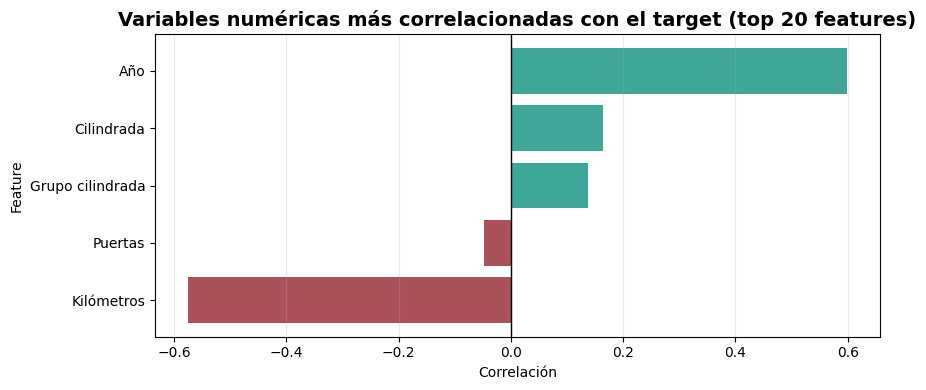

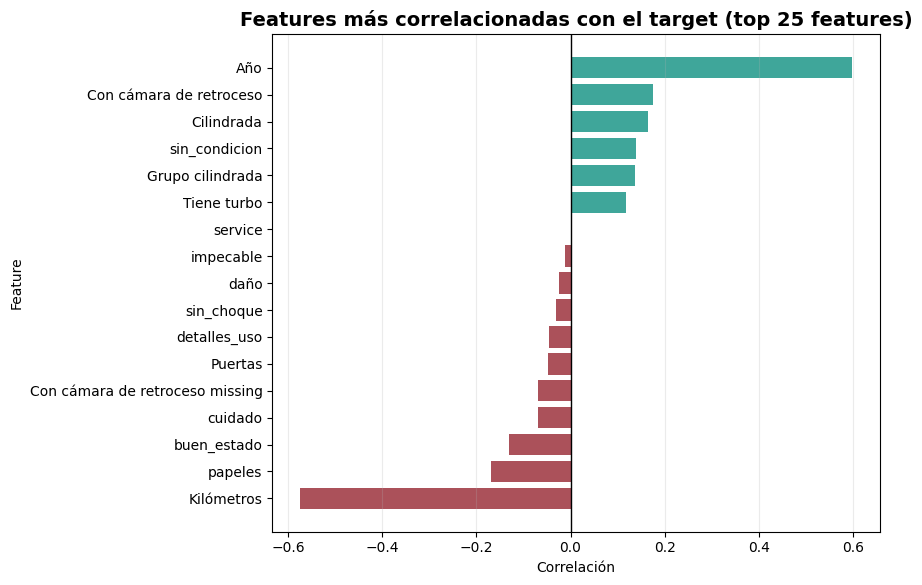

In [ ]:
train_encoded = visual.build_plot_dataset(X_train_encoded, y_train)

visual.plot_numeric_and_binary_correlation_heatmap(
    train_encoded,
    title="Correlación de variables numéricas y binarias no one-hot",
)

numeric_corr_table = visual.plot_top_target_correlations(
    train_encoded,
    feature_type="numeric",
    top_n=20,
    title="Variables numéricas más correlacionadas con el target",
)

all_corr_table = visual.plot_top_target_correlations(
    train_encoded,
    feature_type="both",
    top_n=25,
    title="Features más correlacionadas con el target",
)